In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('fusiontech_reviews.csv')
df.head()

Matplotlib is building the font cache; this may take a moment.


,rating,title_x,text,asin,user_id,timestamp,helpful_vote,main_category,title_y,average_rating,...,categories,bought_together,subtitle,author,num_reviews,avg_helpful_votes,id,os,color,brand
0,5,Fast!,I have been using laptops for the past 30 year...,B089HR6CQP,AHV6QCNBJNSGLATP56JAWJ3C4G2A,1.600000e+12,0,Computers,"FusionTech Gaming G3 15 3500, 15.6 inch FHD La...",4.4,...,"[Electronics, Computers & Accessories, Compute...",NaN,NaN,NaN,114,4.86,0,Windows 10 Home,Black,FusionTech
1,5,Works Great - No Problems - Great Value for Price,"I read a bunch of negative reviews, so I wante...",B089HR6CQP,AFNC5IF4WHTXND7NFTXIKBHQKZ7A,1.630000e+12,0,Computers,"FusionTech Gaming G3 15 3500, 15.6 inch FHD La...",4.4,...,"[Electronics, Computers & Accessories, Compute...",NaN,NaN,NaN,114,4.86,1,Windows 10 Home,Black,FusionTech
2,5,Excellent gaming computer for the price,"Runs smooth, fast, and works well for gaming. ...",B089HR6CQP,AFOPOR5RN7JTWVXC72ITV7XJXIXA,1.610000e+12,0,Computers,"FusionTech Gaming G3 15 3500, 15.6 inch FHD La...",4.4,...,"[Electronics, Computers & Accessories, Compute...",NaN,NaN,NaN,114,4.86,2,Windows 10 Home,Black,FusionTech
3,1,Overheating on setup,I'm impressed. I've never seen a computer so w...,B089HR6CQP,AEQBZ7WR6AYATE3WRWD2LVD74FOA,1.630000e+12,0,Computers,"FusionTech Gaming G3 15 3500, 15.6 inch FHD La...",4.4,...,"[Electronics, Computers & Accessories, Compute...",NaN,NaN,NaN,114,4.86,3,Windows 10 Home,Black,FusionTech
4,1,Don’t buy,"I bought 2 of these laptops, asked for replace...",B089HR6CQP,AGLZUC53J6SZNIXLOECZ7GOIZFNQ,1.610000e+12,22,Computers,"FusionTech Gaming G3 15 3500, 15.6 inch FHD La...",4.4,...,"[Electronics, Computers & Accessories, Compute...",NaN,NaN,NaN,114,4.86,4,Windows 10 Home,Black,FusionTech


In [8]:
#rename columns for clarity
df = df.rename(columns={
    'title_x': 'review_title',
    'title_y': 'product_name',
    'text': 'review_body',
    'asin': 'product_id'
})

#drop rows with missing review body
df = df.dropna(subset=['review_body'])

#drop columns that are not needed for analysis 
df = df.drop(['bought_together', 'subtitle', 'author', 'brand', 'store'], axis=1)

#convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df.head()

,rating,review_title,review_body,product_id,user_id,timestamp,helpful_vote,main_category,product_name,average_rating,rating_number,features,price,categories,num_reviews,avg_helpful_votes,id,os,color
0,5,Fast!,I have been using laptops for the past 30 year...,B089HR6CQP,AHV6QCNBJNSGLATP56JAWJ3C4G2A,1970-01-01 00:26:40,0,Computers,"FusionTech Gaming G3 15 3500, 15.6 inch FHD La...",4.4,613,[15.6 inch FHD (1920 x 1080) 120Hz 250 nits WV...,799.0,"[Electronics, Computers & Accessories, Compute...",114,4.86,0,Windows 10 Home,Black
1,5,Works Great - No Problems - Great Value for Price,"I read a bunch of negative reviews, so I wante...",B089HR6CQP,AFNC5IF4WHTXND7NFTXIKBHQKZ7A,1970-01-01 00:27:10,0,Computers,"FusionTech Gaming G3 15 3500, 15.6 inch FHD La...",4.4,613,[15.6 inch FHD (1920 x 1080) 120Hz 250 nits WV...,799.0,"[Electronics, Computers & Accessories, Compute...",114,4.86,1,Windows 10 Home,Black
2,5,Excellent gaming computer for the price,"Runs smooth, fast, and works well for gaming. ...",B089HR6CQP,AFOPOR5RN7JTWVXC72ITV7XJXIXA,1970-01-01 00:26:50,0,Computers,"FusionTech Gaming G3 15 3500, 15.6 inch FHD La...",4.4,613,[15.6 inch FHD (1920 x 1080) 120Hz 250 nits WV...,799.0,"[Electronics, Computers & Accessories, Compute...",114,4.86,2,Windows 10 Home,Black
3,1,Overheating on setup,I'm impressed. I've never seen a computer so w...,B089HR6CQP,AEQBZ7WR6AYATE3WRWD2LVD74FOA,1970-01-01 00:27:10,0,Computers,"FusionTech Gaming G3 15 3500, 15.6 inch FHD La...",4.4,613,[15.6 inch FHD (1920 x 1080) 120Hz 250 nits WV...,799.0,"[Electronics, Computers & Accessories, Compute...",114,4.86,3,Windows 10 Home,Black
4,1,Don’t buy,"I bought 2 of these laptops, asked for replace...",B089HR6CQP,AGLZUC53J6SZNIXLOECZ7GOIZFNQ,1970-01-01 00:26:50,22,Computers,"FusionTech Gaming G3 15 3500, 15.6 inch FHD La...",4.4,613,[15.6 inch FHD (1920 x 1080) 120Hz 250 nits WV...,799.0,"[Electronics, Computers & Accessories, Compute...",114,4.86,4,Windows 10 Home,Black


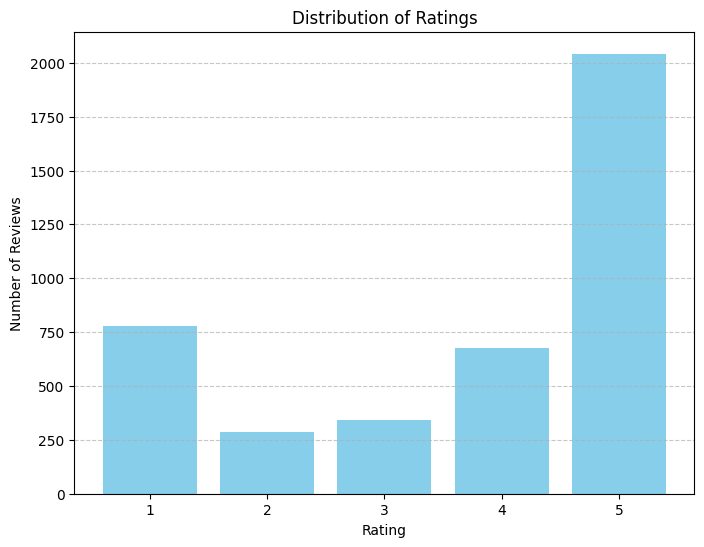

In [ ]:
rating_counts = df['rating'].value_counts().sort_index()

# bar chart to show distribution of ratings
plt.figure(figsize=(8, 6))

plt.bar(rating_counts.index, rating_counts.values, color='skyblue')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Ratings')
plt.xticks(rating_counts.index)  
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


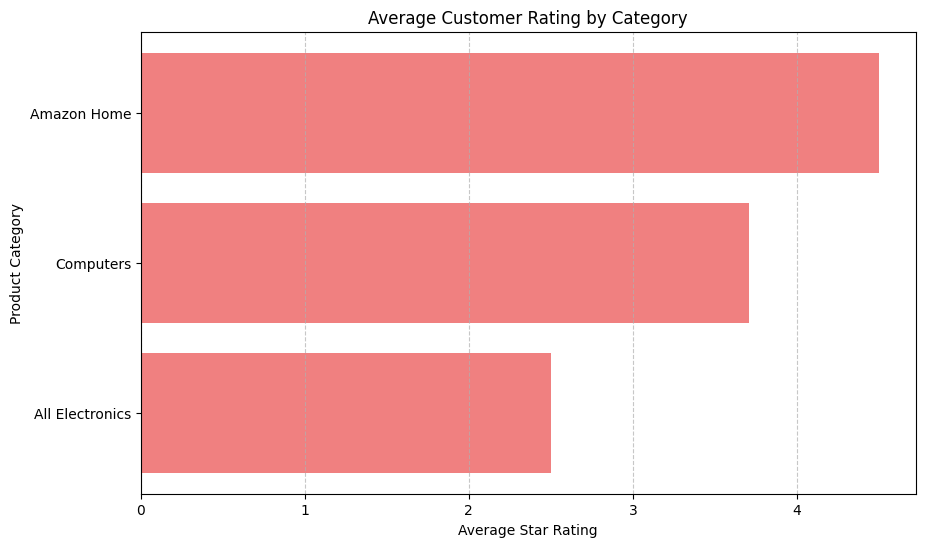

In [ ]:
category_ratings = df.groupby('main_category')['rating'].mean().sort_values()

plt.figure(figsize=(10, 6))
# horizontal bar chart to show average rating by category
plt.barh(category_ratings.index, category_ratings.values, color='lightcoral')
plt.xlabel('Average Star Rating')
plt.ylabel('Product Category')
plt.title('Average Customer Rating by Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

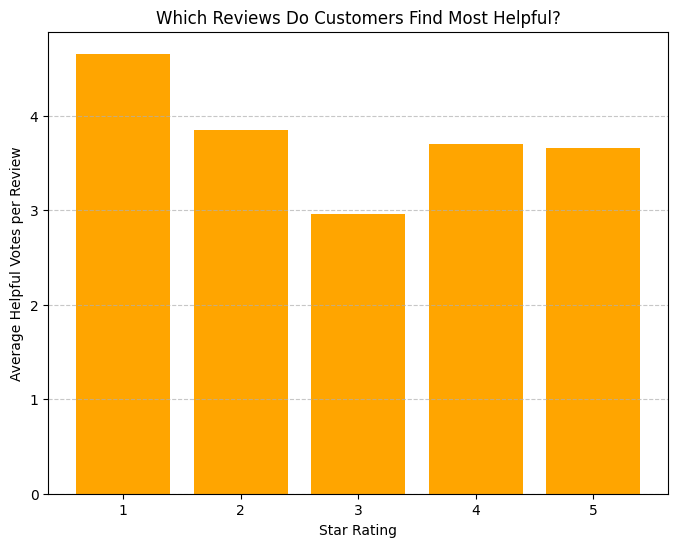

In [ ]:
helpful_by_rating = df.groupby('rating')['helpful_vote'].mean()

# bar chart to show average helpful votes by rating

plt.figure(figsize=(8, 6))
plt.bar(helpful_by_rating.index, helpful_by_rating.values, color='orange')
plt.xlabel('Star Rating')
plt.ylabel('Average Helpful Votes per Review')
plt.title('Which Reviews Do Customers Find Most Helpful?')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()